In [1]:
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import heapq

from joblib import Parallel, delayed
from scipy import stats
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
# Set the default font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams["mathtext.fontset"] = 'stix'

In [2]:
num_pnts = 9
runs = 10
infection_model = 'acute'
sample_virs = np.array(np.meshgrid(b_I*np.linspace(0.5, 2.5, num_pnts), # vary b_I
                                   S_max*np.logspace(-3.0, 0, num_pnts), # vary K_I
                                   np.array([0.5]), # vary d_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-1, 2, num_pnts), # vary N_0
                                   I_min*np.array([1.0]), # vary I_0
                                   np.array([S_max]), # vary K_S
                                        np.array([d_IE]), # vary d_IE
                                        np.array([d_H]), # vary d_H
                                        np.array([max_Na]), # vary max_Na
                                        np.array([max_expand]) # vary max_expand
                                           )).T.reshape(-1,11)

Na_regulation = [2, 0.0, -0.5, -0.25*L0_max]
NE_regulation = [2, 0.0, -0.5, -1.0*L0_max]
EM_regulation = [-0, -0, 0, -L0_max**3]
Edie_regulation = [-2, -0.0, 0.5, -0.0*L0_max]
default_reg = np.array([Na_regulation + NE_regulation + EM_regulation + Edie_regulation])

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
# d="_local_data/"

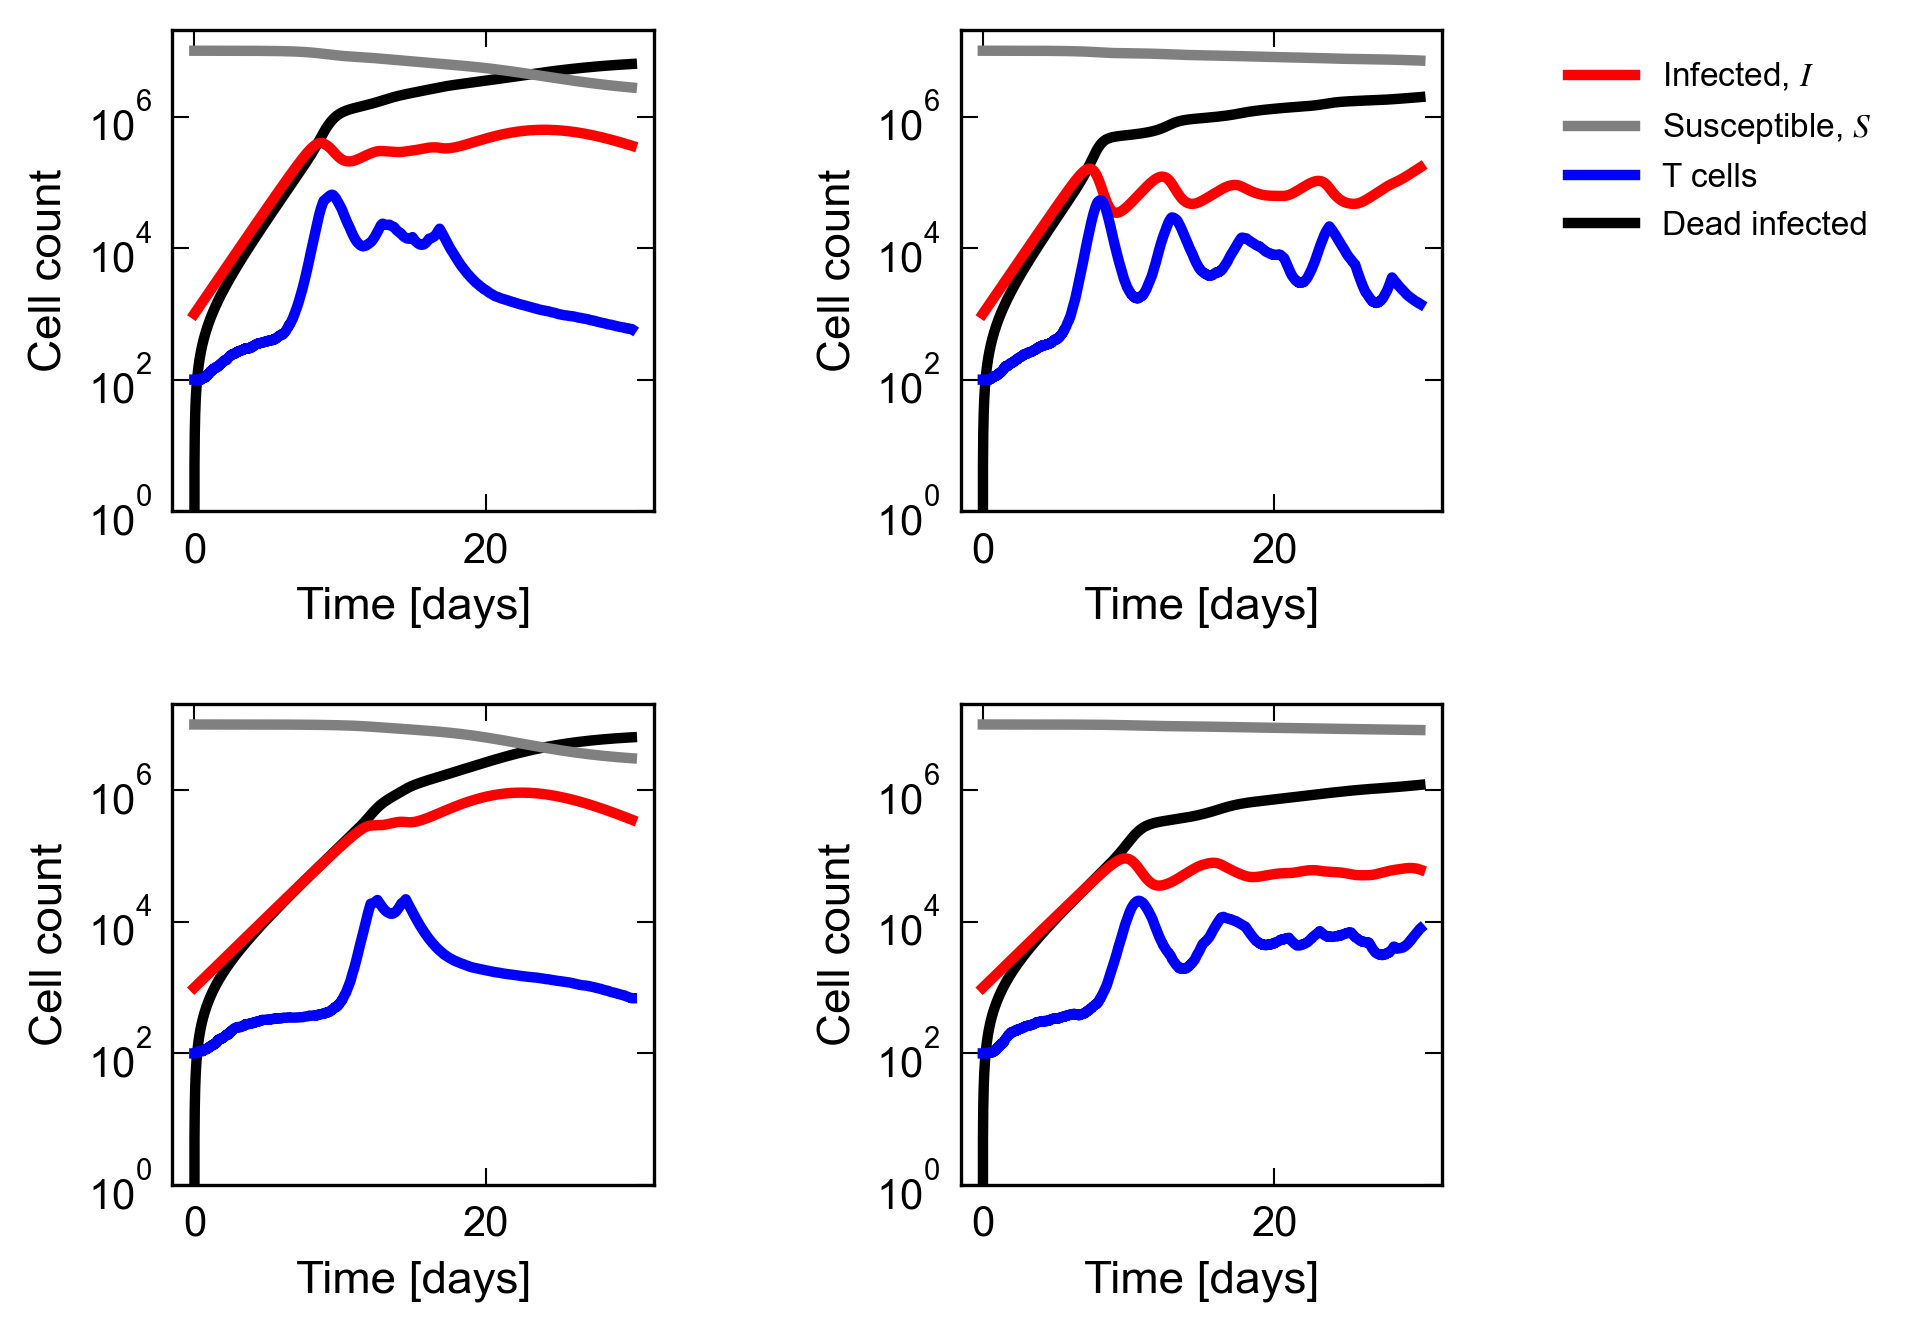

In [3]:
# Plot select infection responses
fig, axs = plt.subplots(2,2, dpi = 150, sharex = False, sharey = False, figsize=(6,5))

scenarios = np.array(np.meshgrid(np.array([np.amax(infection_sample[:,2])]), # vary d_I
                                 np.array([heapq.nlargest(6, np.unique(infection_sample[:,1]))[5], heapq.nsmallest(6, np.unique(infection_sample[:,1]))[2]]), # vary K_I
                                 np.array([heapq.nlargest(6, np.unique(infection_sample[:,0]))[5], heapq.nsmallest(6, np.unique(infection_sample[:,0]))[2]]), # vary b_I
                                 np.array([np.amax(infection_sample[:,3])]), # vary K_H
                                 np.array([np.amax(infection_sample[:,4])]), # vary N_0
                                 np.array([np.amax(infection_sample[:,5])]), # vary I_0
                                 np.array([S_max]) # vary K_S
                                           )).T.reshape(-1,7)

var_labels = ["antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", 
              "lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
labels = ['low ' + var_labels[0]+' fast '+var_labels[1],
          'high ' + var_labels[0]+' fast '+var_labels[1],
          'low ' + var_labels[0]+' slow '+var_labels[1],
          'high ' + var_labels[0]+' slow '+var_labels[1]]
cmap_colors = sns.color_palette('tab20', 20)

# Loop and do 
for k, v in enumerate(scenarios):
    y, x = k % 2, k // 2

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[x,y].plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
    axs[x,y].plot(ts, S, 'grey', label = r'Susceptible, $S$', linewidth=2.5)
    axs[x,y].plot(ts, N + Na + E + M, 'blue', linewidth=2.5, label = r'T cells')
    axs[x,y].plot(ts, I_d_I, 'black', zorder = 1, linewidth=2.5, label = r'Dead infected')

    # axs[x,y].set_title(labels[k], fontsize = 8.0, pad = 0.1)
    axs[x,y].set_box_aspect(1)
    axs[x,y].semilogy()
    axs[x,y].minorticks_off()
    axs[x,y].set_ylim(1,)

for j, ax in enumerate(axs.flat):
    if j == 1:
        ax.legend(bbox_to_anchor=(1.2, 1), framealpha=0, ncol = 1, fontsize = 8)
    ax.set_ylabel('Cell count', fontsize = 11)
    ax.set_xlabel(r"Time [days]", fontsize = 11)
fig.subplots_adjust(wspace=.3, hspace=0.40)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-dynamics-simple.png', dpi=300, bbox_inches="tight")

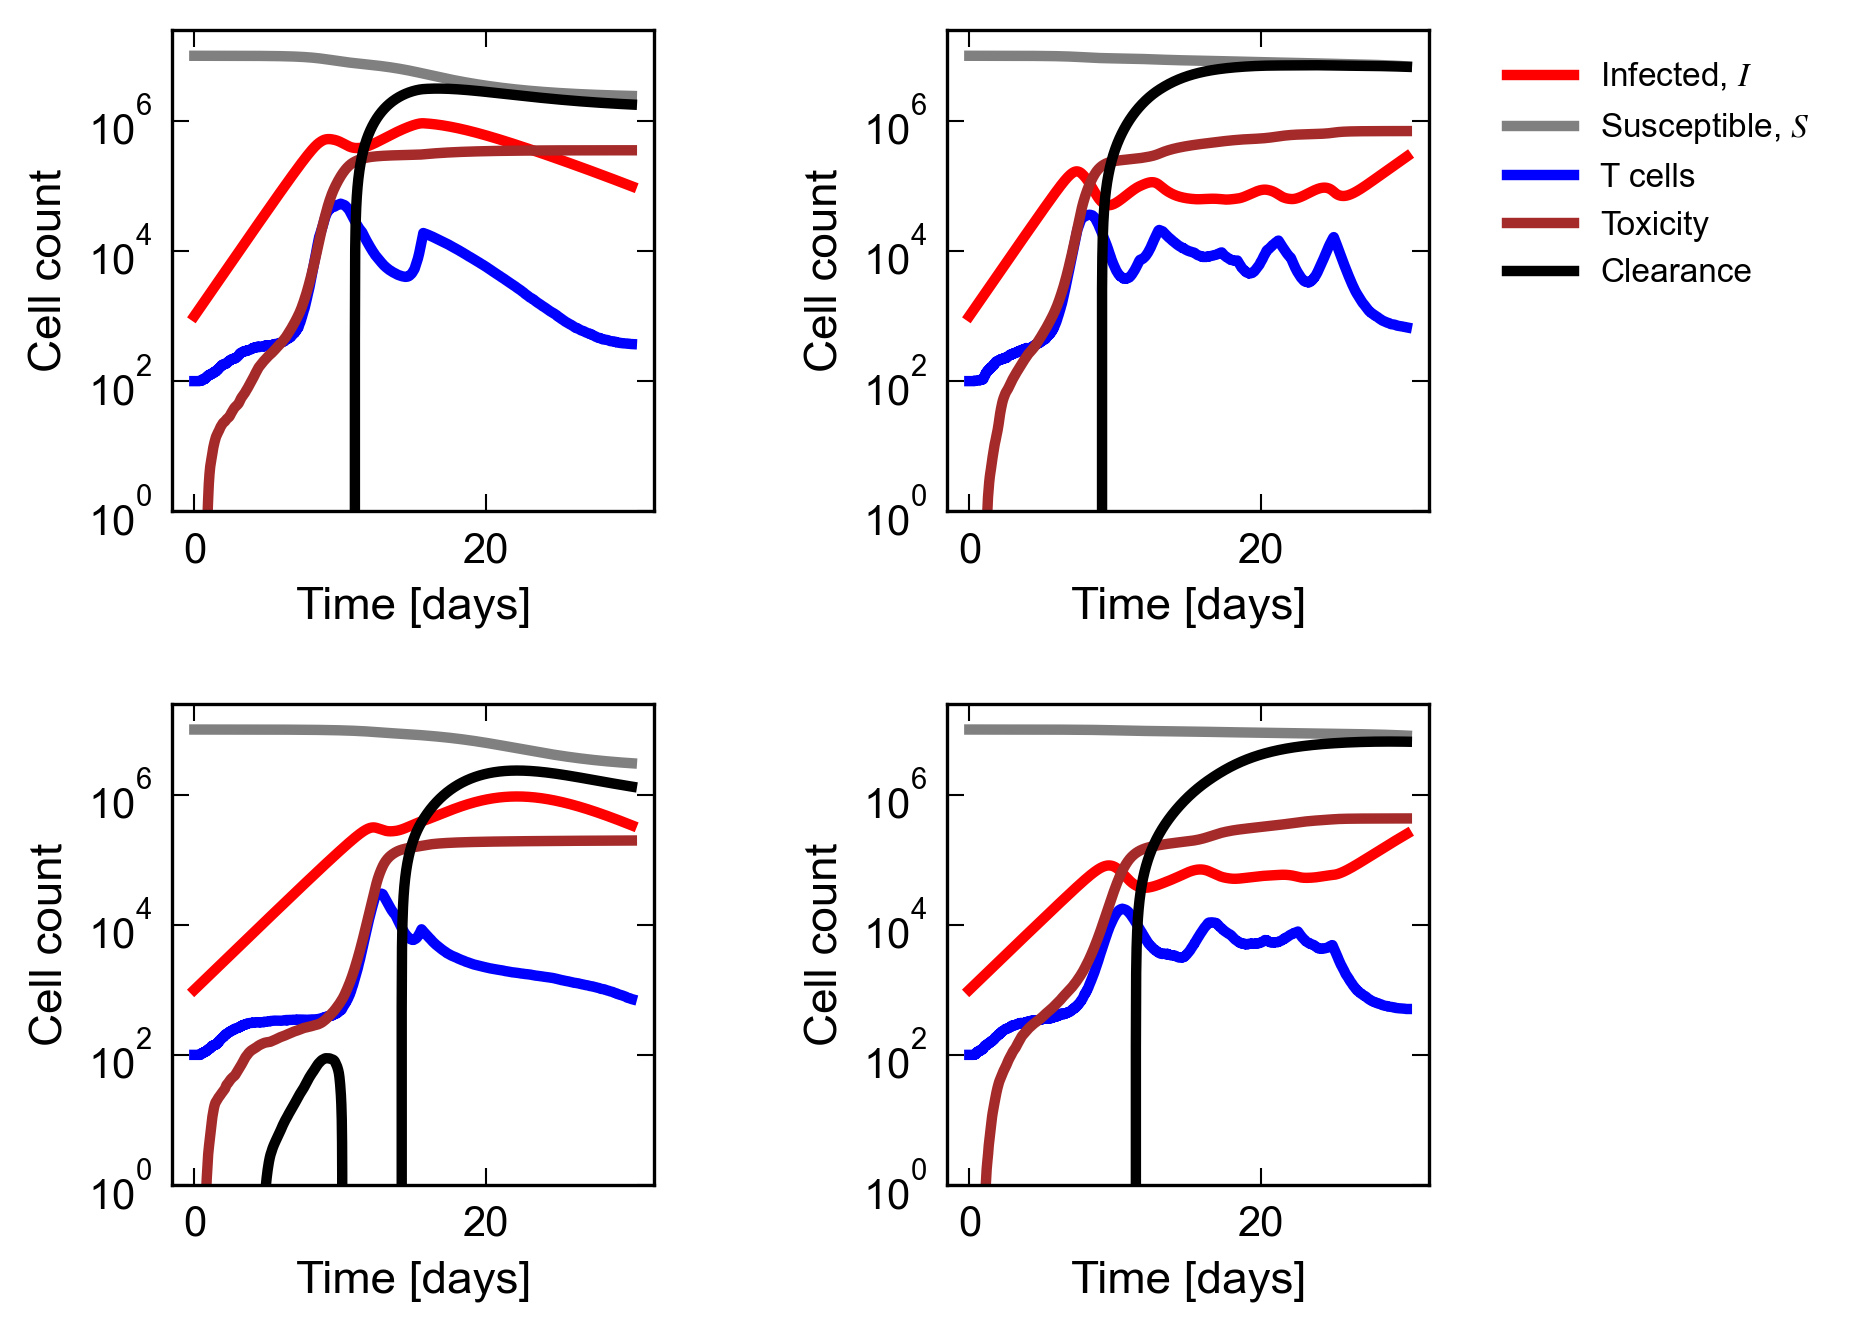

In [4]:
# Plot select infection responses
fig, axs = plt.subplots(2,2, dpi = 150, sharex = True, sharey = True, figsize=(6,5))

var_labels = ["antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", 
              "lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
labels = ['low ' + var_labels[0]+' fast '+var_labels[1],
          'high ' + var_labels[0]+' fast '+var_labels[1],
          'low ' + var_labels[0]+' slow '+var_labels[1],
          'high ' + var_labels[0]+' slow '+var_labels[1]]
cmap_colors = sns.color_palette('tab20', 20)

# Loop and do 
for k, v in enumerate(scenarios):
    y, x = k % 2, k // 2

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[x,y].plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
    axs[x,y].plot(ts, S, 'grey', label = r'Susceptible, $S$', linewidth=2.5)
    axs[x,y].plot(ts, N + Na + E + M, 'blue', linewidth=2.5, label = r'T cells')
    axs[x,y].plot(ts, I_d_S, 'brown', linewidth=2.5, label = r'Toxicity')
    # axs[x,y].plot(ts, I_d_I, 'black', linewidth=2.5, label = r'Dead infected')

    # Run simulation without immune cells
    data_dict = lin_stoch_sim(N_0 = 0.0,
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    
    S, I, N, Na, E, M, HI, I_d_I_noimm, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    axs[x,y].plot(ts, I_d_I_noimm - I_d_I, 'black', linewidth=2.5, linestyle = '-', label = r'Clearance')

    # axs[x,y].set_title(labels[k], fontsize = 8.0, pad = 0.1)
    axs[x,y].set_box_aspect(1)
    axs[x,y].semilogy()
    axs[x,y].minorticks_off()
    axs[x,y].set_ylim(1,)
    axs[x,y].xaxis.set_tick_params(labelbottom=True)
    axs[x,y].yaxis.set_tick_params(labelleft=True)

for j, ax in enumerate(axs.flat):
    if j == 1:
        ax.legend(bbox_to_anchor=(1.1, 1), framealpha=0, ncol = 1, fontsize = 8) # 
    ax.set_ylabel('Cell count', fontsize = 11)
    ax.set_xlabel(r"Time [days]", fontsize = 11)
fig.subplots_adjust(wspace=.25, hspace=0.40)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-dynamics.png', dpi=300, bbox_inches="tight")

In [5]:
# Set infection parameters
v = np.array([d_I, 1.0e+05, 2.00000000e-07, 1.00000000e+04, 1.00000000e+02, 1.00000000e+03, S_max])

In [6]:
n_steps = 2
vary_ps = np.array(np.meshgrid(np.array([0.0]),
                               np.array([0.0]),
                               np.array([0.0]),
                               L0_max*np.linspace(-1/2, 1/2, n_steps),
                               L0_max*np.linspace(-1/2, 1/2, n_steps),
                               L0_max*np.linspace(-1/2, 1/2, n_steps))).T.reshape(-1,6)

kwargs = {'linewidth': 4.0, 'markeredgewidth': 0.25, 'markeredgecolor': 'k', 'markersize': 6, 'alpha': 0.75}

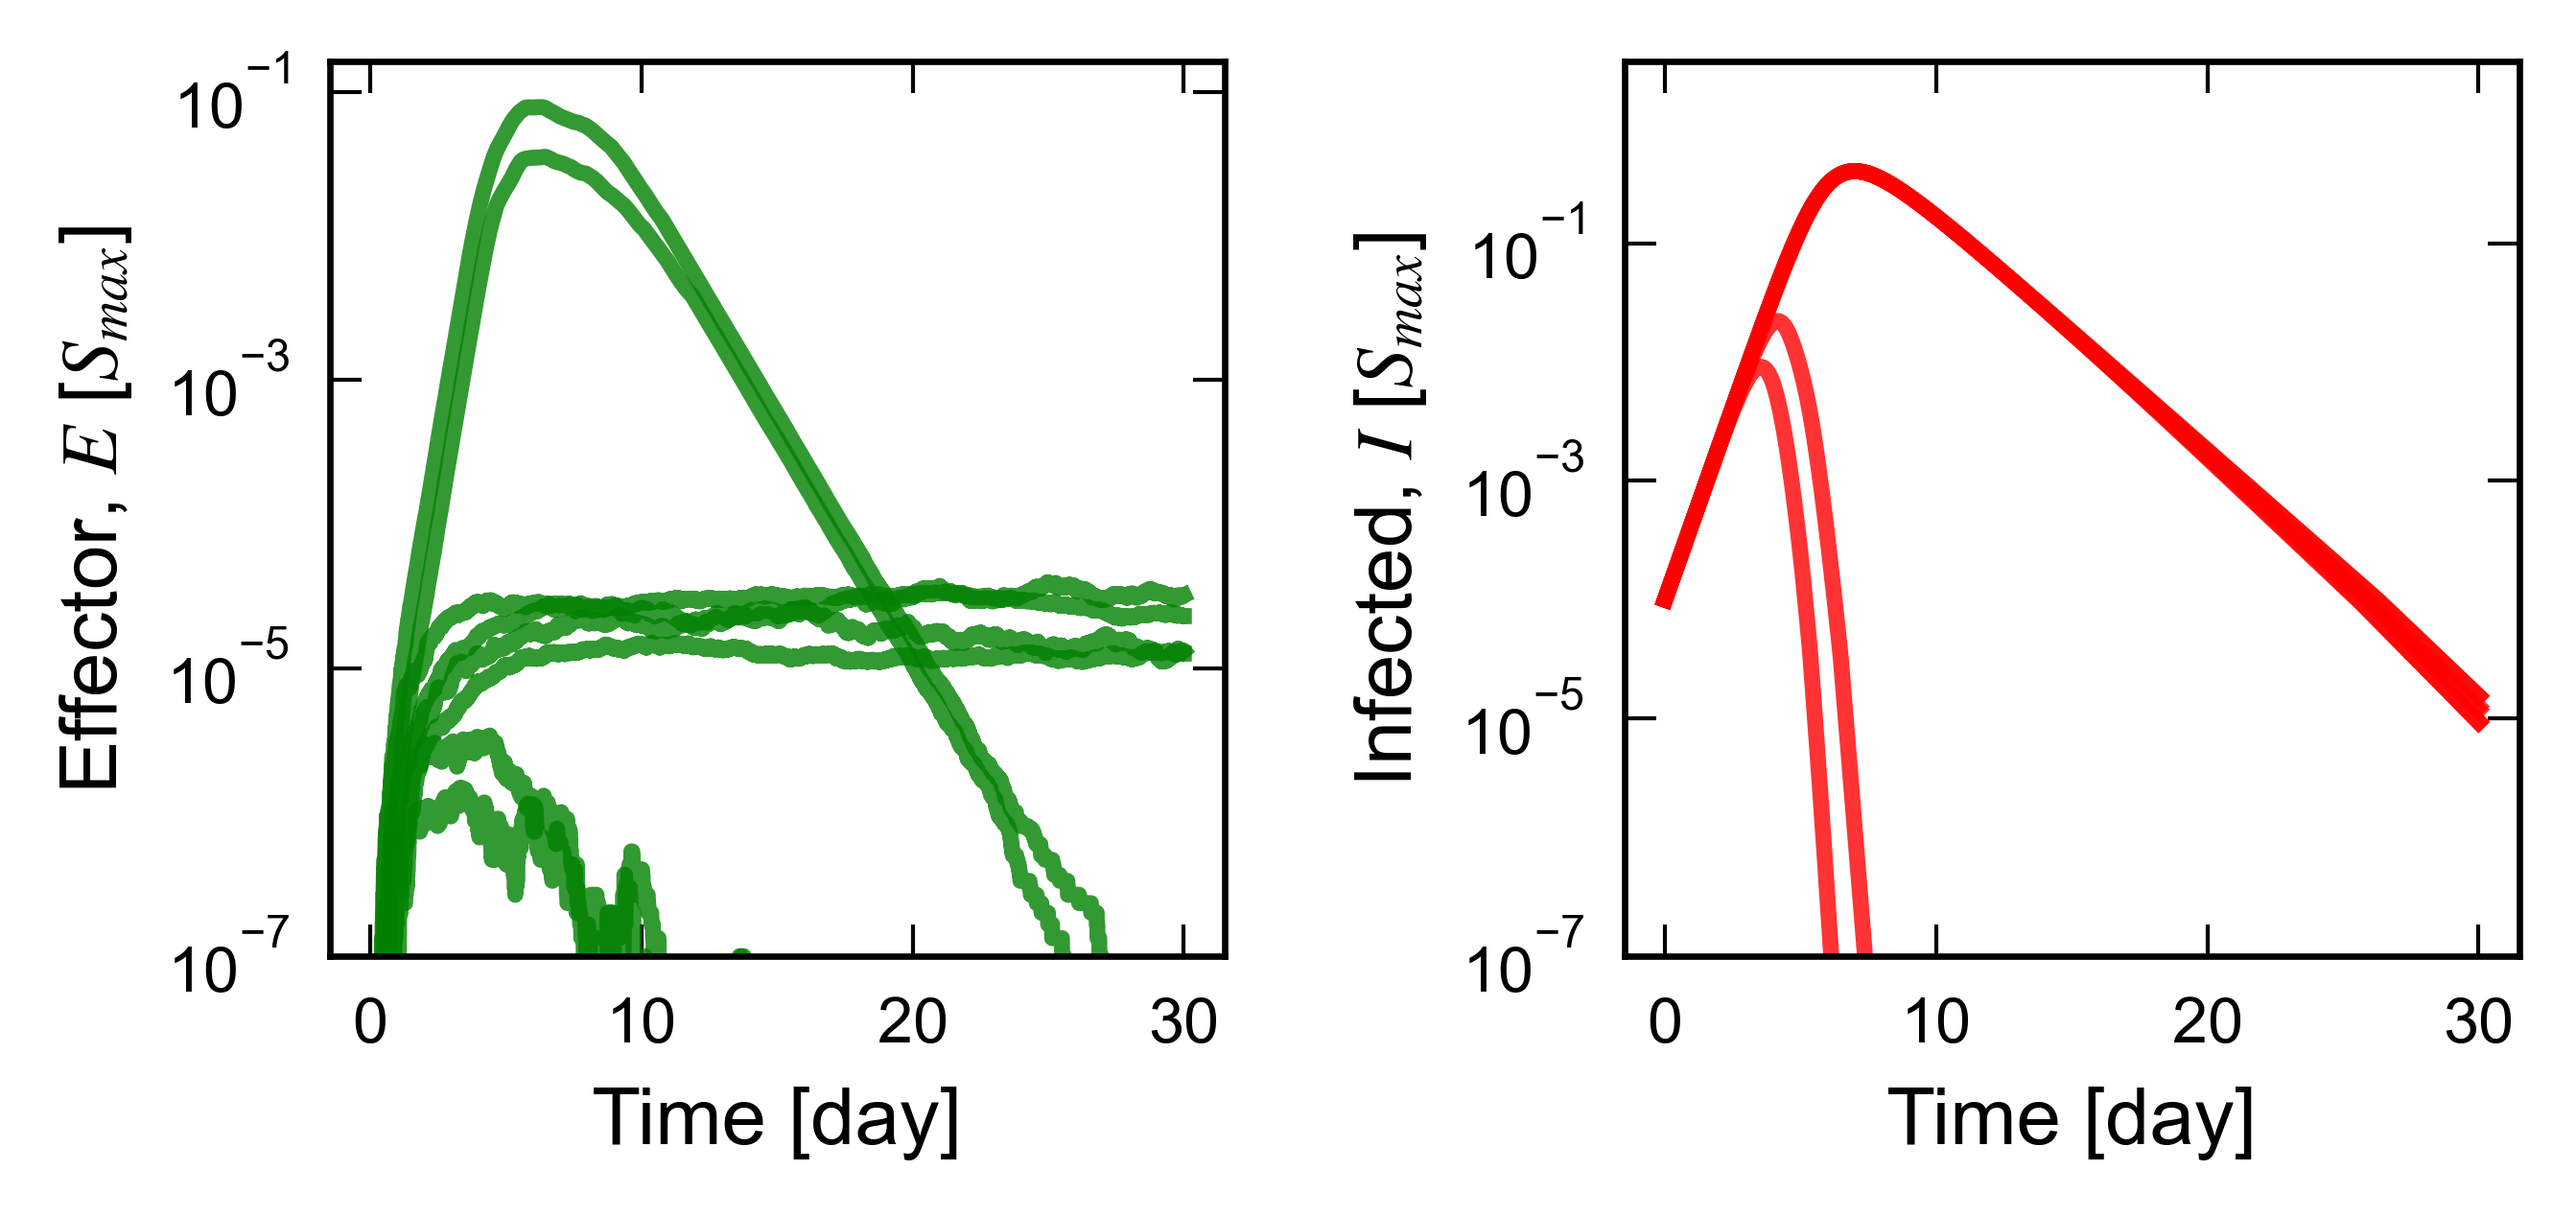

In [7]:
# Plot select infection responses
fig, axs = plt.subplots(1,2, dpi = 300, sharex = 'row', sharey = False, figsize=(4.5, 2), layout='constrained')
repeat = 3
store_runs = []
# Loop and vary pareto designs 
for k, p in enumerate(vary_ps):
    dyn = 0

    for j in np.arange(0, repeat):
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[5],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  K_S = v[6],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 2*sim_steps)
        
        dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]
        sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0]/repeat, dyn[:,1]/repeat, dyn[:,2]/repeat, dyn[:, 3]/repeat, dyn[:,4]/repeat, dyn[:,5]/repeat, dyn[:,6]/repeat, dyn[:,7]/repeat, dyn[:,8]/repeat, dyn[:,9]/repeat

    # Plot cell dynamics
    axs[0].plot(ts, E/S_max, color = 'green', linewidth = 2.0, alpha = 0.8)
    axs[1].plot(ts, I/S_max, color = 'red', linewidth = 2.0, alpha = 0.8)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j == 0:
        ax.set_ylabel(r'Effector, $E$ [$S_{max}$]', fontsize = 10)
        ax.set_xlabel(r"Time [day]", fontsize = 10)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
    elif j == 1:
        ax.set_ylabel(r'Infected, $I$ [$S_{max}$]', fontsize = 10)
        ax.set_xlabel(r"Time [day]", fontsize = 10)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
        
    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

# fig.subplots_adjust(wspace=.65, hspace=0.15)

plt.savefig('_figs/figSI_'+infection_model+'-example-vary-baseline-eff-dynamics'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")

In [8]:
n_steps = 7
p_default = np.array([0*psi_max, 0*psi_max, 0*psi_max, 
                      0*L0_max, 0*L0_max,-0*L0_max, 0.0])
vary_ps = np.tile(p_default,  (n_steps*(len(p_default) - 1), 1))

for i in np.arange(len(p_default) - 1):
    vary_ps[i*n_steps:(i+1)*n_steps, i] = np.linspace(-psi_max, psi_max, n_steps) if i < 3 else np.linspace(-L0_max, L0_max, n_steps)
    vary_ps[i*n_steps:(i+1)*n_steps, -1] = i

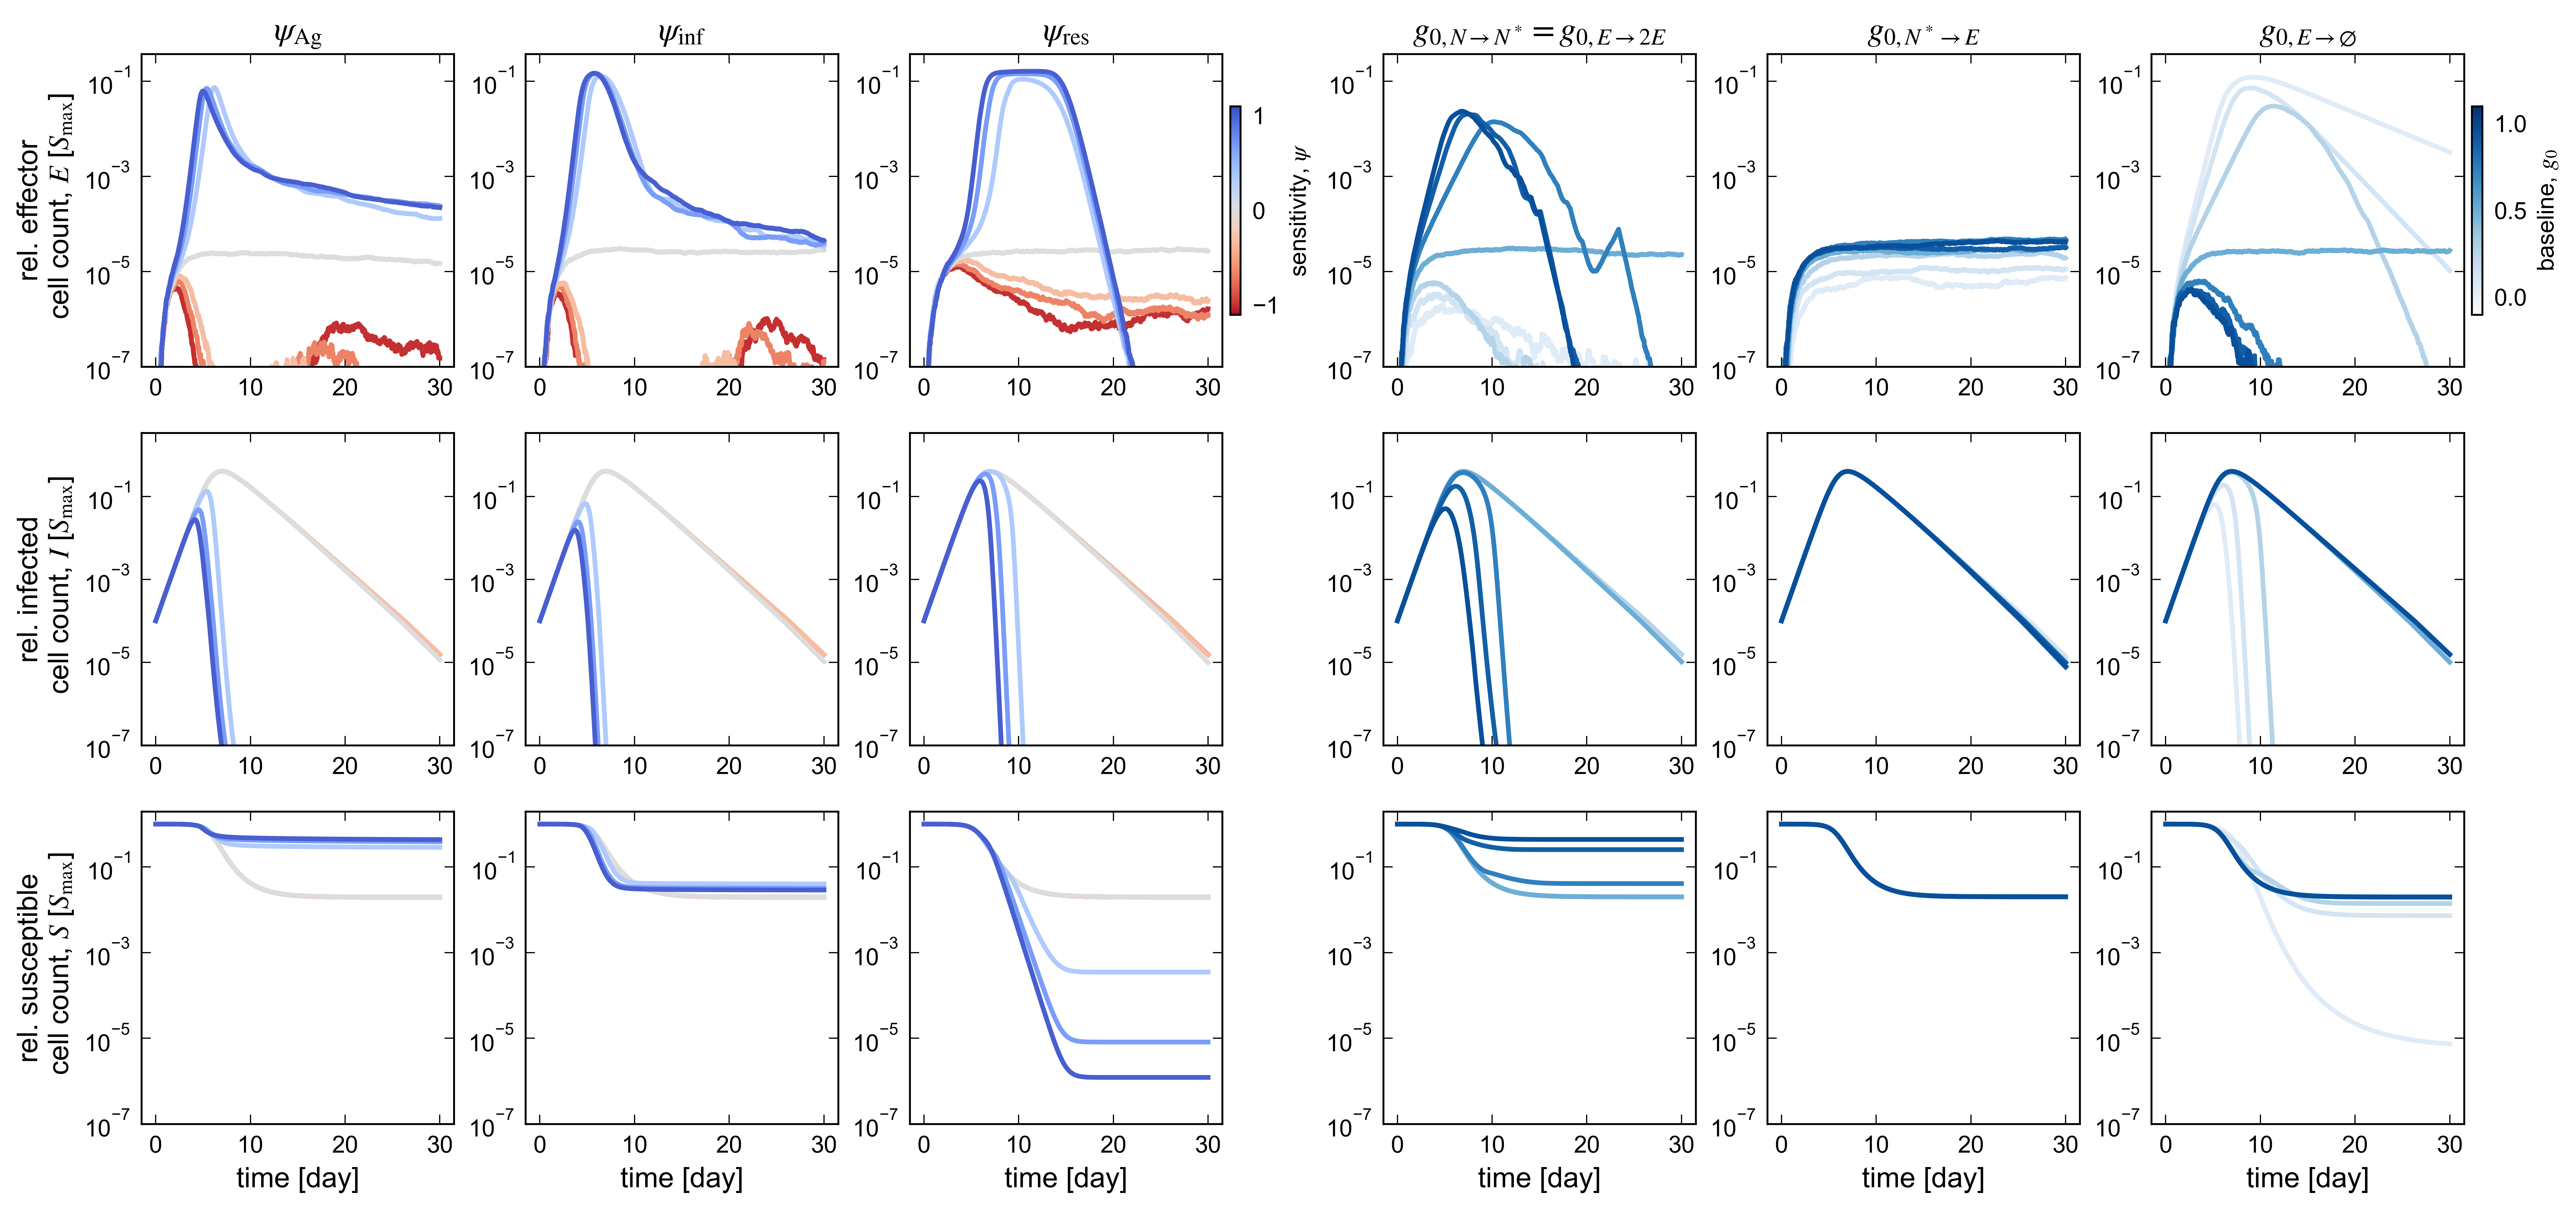

In [9]:
# Plot select infection responses
fig, axs = plt.subplots(3,6, dpi = 300, sharex = 'row', sharey = 'row', figsize=(2*6 + 3, 7), layout='constrained')
repeat = 10
store_runs = []
sm1 = cm.ScalarMappable(norm = mcolors.Normalize(vmin=-1.1, vmax=1.1), cmap=mpl.colormaps.get_cmap('coolwarm_r'))
sm2 = cm.ScalarMappable(norm = mcolors.Normalize(vmin=-0.1, vmax=1.1), cmap=mpl.colormaps.get_cmap('Blues'))
# Loop and do 
for k, p in enumerate(vary_ps):
    # if k % 3 == 0:
    # Vary pareto designs
    index = int(p[-1])
    dyn = 0

    for j in np.arange(0, repeat):
        data_dict = lin_stoch_sim(N_0 = v[4],
                                  I_0 = v[5],
                                  b_I = v[2], 
                                  K_I = v[1],
                                  d_I = v[0],
                                  K_H = v[3],
                                  NE_regulation = [p[0], p[1], p[2], p[4]],
                                  EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max**4],
                                  activation_regulation = [p[0], p[1], p[2], p[3]],
                                  contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                                  infection_model = 'acute',
                                  reg_model = 'mwc_like',
                                  out_data = "full",
                                  memory_death = False,
                                  duration = 1.0*sim_duration,
                                  steps = 4*sim_steps)
        
        dyn += data_dict["cell_time_series"]
        ts = data_dict["time"]
        sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0]/repeat, dyn[:,1]/repeat, dyn[:,2]/repeat, dyn[:, 3]/repeat, dyn[:,4]/repeat, dyn[:,5]/repeat, dyn[:,6]/repeat, dyn[:,7]/repeat, dyn[:,8]/repeat, dyn[:,9]/repeat

    # Plot cell dynamics
    axs[0, index].plot(ts, E/S_max, linewidth=2.0, color = sm1.to_rgba(p[index]/psi_max) if index < 3 else sm2.to_rgba(1/(1 + np.exp(-p[index]))), alpha = 1.0)
    axs[1, index].plot(ts, I/S_max, linewidth=2.0, color = sm1.to_rgba(p[index]/psi_max) if index < 3 else sm2.to_rgba(1/(1 + np.exp(-p[index]))), alpha = 1.0)
    axs[2, index].plot(ts, S/S_max, linewidth=2.0, color = sm1.to_rgba(p[index]/psi_max) if index < 3 else sm2.to_rgba(1/(1 + np.exp(-p[index]))), alpha = 1.0)
    axs[0, index].set_title(opt_vars_labels[index], fontsize = 14)
#     axs[3, index].scatter(p[index], sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[0], s = 9.5, ec = 'black', label = 'Start time [day]' if k == 0 else '') #Effector start time
#     axs[3, index].scatter(p[index], sim_summary[6] - sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[1], ec = 'black', s = 9.5, label = 'Expansion time [day]' if k == 0 else '') # Effector peak time
#     axs[3, index].scatter(p[index], (sim_summary[10] - sim_summary[6]), color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[2], ec = 'black', s = 9.5, label = 'End time' if k == 0 else '') # Effector end time
#     axs[3, index].scatter(p[index], np.amax(E)/v[4], color = cmap_colors[index], linewidths = 0.5,
#                           marker = reg_markers[3], ec = 'black', s = 9.5, label = r'Resp. expansion [$N_0$]' if k == 0 else '') # Effector peak magnitude
    
#     axs[0, index].set_title(opt_vars_labels[index], fontsize = 12)

#     store_runs.append( (p.tolist() + [sim_summary[7], sim_summary[6] - sim_summary[7], sim_summary[10] - sim_summary[6], np.amax(E)/v[4], sim_summary[8]/v[4], sim_summary[9]]) )

# axs[3, 0].legend(fontsize=5.5, framealpha=0, ncol = 1) # bbox_to_anchor=(1.0, 1.55),
cb1 = fig.colorbar(sm1, ax=axs[0, 2], location='right', shrink = 0.6, pad = 0.025)
cb1.set_label('sensitivity, $\psi$', fontsize = 10)
cb1.ax.tick_params(labelsize=10)
cb2 = fig.colorbar(sm2, ax=axs[0, -1], location='right', shrink = 0.6, pad = 0.025)
cb2.set_label('baseline, $g_0$', fontsize = 10)
cb2.ax.tick_params(labelsize=10)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j // 6 == 0:
        if j % 6 == 0:
            ax.set_ylabel('rel. effector\n cell count, '+r'$E$ [$S_\text{max}$]', fontsize = 12)
        #ax.set_xlabel(r"time [day]", fontsize = 12)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
    elif j // 6 == 1:
        if j % 6 == 0:
            ax.set_ylabel('rel. infected\n cell count, '+r'$I$ [$S_\text{max}$]', fontsize = 12)
        #ax.set_xlabel(r"time [day]", fontsize = 12)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
    elif j // 6 == 2:
        if j % 6 == 0:
            ax.set_ylabel('rel. susceptible\n cell count, '+r'$S$ [$S_\text{max}$]', fontsize = 12)
        ax.set_xlabel(r"time [day]", fontsize = 12)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1/S_max,)
    # else:
    #     ax.set_xlabel(opt_vars_labels[j % 6], fontsize = 12)
    #     #ax.locator_params(axis='x', nbins=4)
    #     ax.set_ylabel("effector observable", fontsize = 12)
    #     ax.semilogy()
    #     #ax.set_yscale('symlog')

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

# fig.subplots_adjust(wspace=.65, hspace=0.15)

plt.savefig('_figs/fig2_'+infection_model+'-vary_design-eff_dynamics'+'.pdf', format="pdf", transparent=True, dpi=300, bbox_inches="tight")

In [10]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, 
    comment="single-reg-vary-virs", runs = runs, infection_model = infection_model, default_reg = default_reg, 
    num_cpu = 135)

Running 7290 simulations in batch #-1
Saved sim_batch_-1-10-acute-single-reg-vary-virs.pkl
0.042851496934890744 hrs


In [15]:
d_file = d + '/sim_batch_-1-'+str(runs)+'-'+infection_model+'-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

In [16]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
sim_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
use_data = sim_df #.loc[sim_df['b_I']*sim_df['S_max'] >= sim_df['d_I']]
use_data.loc[:,'max_expE'] = use_data.max_pE
use_data.loc[:,"peff_infection"] = use_data['harm_pI'].to_numpy()/S_max
use_data.loc[:,"peff_toxicity"] = use_data['harm_pS'].to_numpy()/S_max
use_data.loc[:,"peff_total_harm"] = use_data['peff_infection'] + use_data['peff_toxicity']

with pd.option_context('display.max_columns', None):
    display(use_data)

,S_0,I_0,b_I,d_S,d_I,d_IE,K_I,d_H,K_H,K_S,N_0,max_Na,max_expand,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_cycle,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_eM,T_pEcyteM,T_pE_end,frac_cM,int_pHE,int_pHI,E_end,max_expE,peff_infection,peff_toxicity,peff_total_harm
0,9999000.0,1000.0,5.000000e-08,0.01,0.5,12.0,1.000000e+04,1.0,10000.0,10000000.0,10.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.952792e-07,0.00,0.01,1.004999e+03,2.717932e+01,7.0,3.37,2.27,0.0,0.0,0.00,0.875000,1.327859e+01,2.521258e+02,0.0,7.0,0.000100,2.717932e-06,0.000103
1,9999000.0,1000.0,5.000000e-08,0.01,0.5,12.0,2.371374e+04,1.0,10000.0,10000000.0,10.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.955107e-07,0.00,0.01,1.004999e+03,4.594922e+01,5.0,2.95,1.46,0.0,0.0,0.00,0.825000,1.627047e+01,2.521226e+02,0.0,5.0,0.000100,4.594922e-06,0.000105
2,9999000.0,1000.0,5.000000e-08,0.01,0.5,12.0,5.623413e+04,1.0,10000.0,10000000.0,10.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.960851e-07,0.00,0.01,1.004999e+03,2.992019e-01,1.0,2.43,1.36,0.0,0.0,0.00,0.975610,2.948125e-01,2.521258e+02,0.0,1.0,0.000100,2.992019e-08,0.000101
3,9999000.0,1000.0,5.000000e-08,0.01,0.5,12.0,1.333521e+05,1.0,10000.0,10000000.0,10.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.960375e-07,0.00,0.01,1.004999e+03,2.204594e+01,4.0,2.09,1.45,0.0,0.0,0.00,0.850000,1.079433e+01,2.521235e+02,0.0,4.0,0.000100,2.204594e-06,0.000103
4,9999000.0,1000.0,5.000000e-08,0.01,0.5,12.0,3.162278e+05,1.0,10000.0,10000000.0,10.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.960717e-07,0.00,0.01,1.004999e+03,1.601447e+01,3.0,2.04,2.24,0.0,0.0,0.00,0.853659,5.860582e+00,2.521258e+02,0.0,3.0,0.000100,1.601447e-06,0.000102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7285,9999000.0,1000.0,2.500000e-07,0.01,0.5,12.0,3.162278e+05,1.0,10000.0,10000000.0,10000.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.890802e+01,4.53,0.00,7.300408e+06,1.276611e+06,702258.0,5.09,1.92,0.0,0.0,6.56,0.750429,2.686813e+06,7.747065e+05,129.0,702258.0,0.730041,1.276611e-01,0.857702
7286,9999000.0,1000.0,2.500000e-07,0.01,0.5,12.0,7.498942e+05,1.0,10000.0,10000000.0,10000.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,2.289650e-01,4.99,27.06,8.911990e+06,3.979754e+05,397580.0,5.66,1.94,0.0,0.0,7.41,0.785739,1.991193e+06,1.390909e+06,0.0,397580.0,0.891199,3.979754e-02,0.930997
7287,9999000.0,1000.0,2.500000e-07,0.01,0.5,12.0,1.778279e+06,1.0,10000.0,10000000.0,10000.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,4.128815e-02,5.31,23.65,9.762588e+06,1.040010e+05,87967.0,6.14,1.93,0.0,0.0,8.10,0.829264,5.050830e+05,1.832694e+06,0.0,87967.0,0.976259,1.040010e-02,0.986659
7288,9999000.0,1000.0,2.500000e-07,0.01,0.5,12.0,4.216965e+06,1.0,10000.0,10000000.0,10000.0,4.0,32768.0,1.0,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,0.0,-0.5,-0.75,2.0,0.0,-0.5,-3.0,0.0,0.0,0.0,-27.0,-2.0,-0.0,0.5,-0.0,4.458990e-02,5.41,23.80,9.884988e+06,3.984146e+04,14067.0,6.32,1.94,0.0,0.0,7.22,0.854569,6.622795e+04,1.959999e+06,0.0,14067.0,0.988499,3.984146e-03,0.9

### Understand noise structure of the simulations

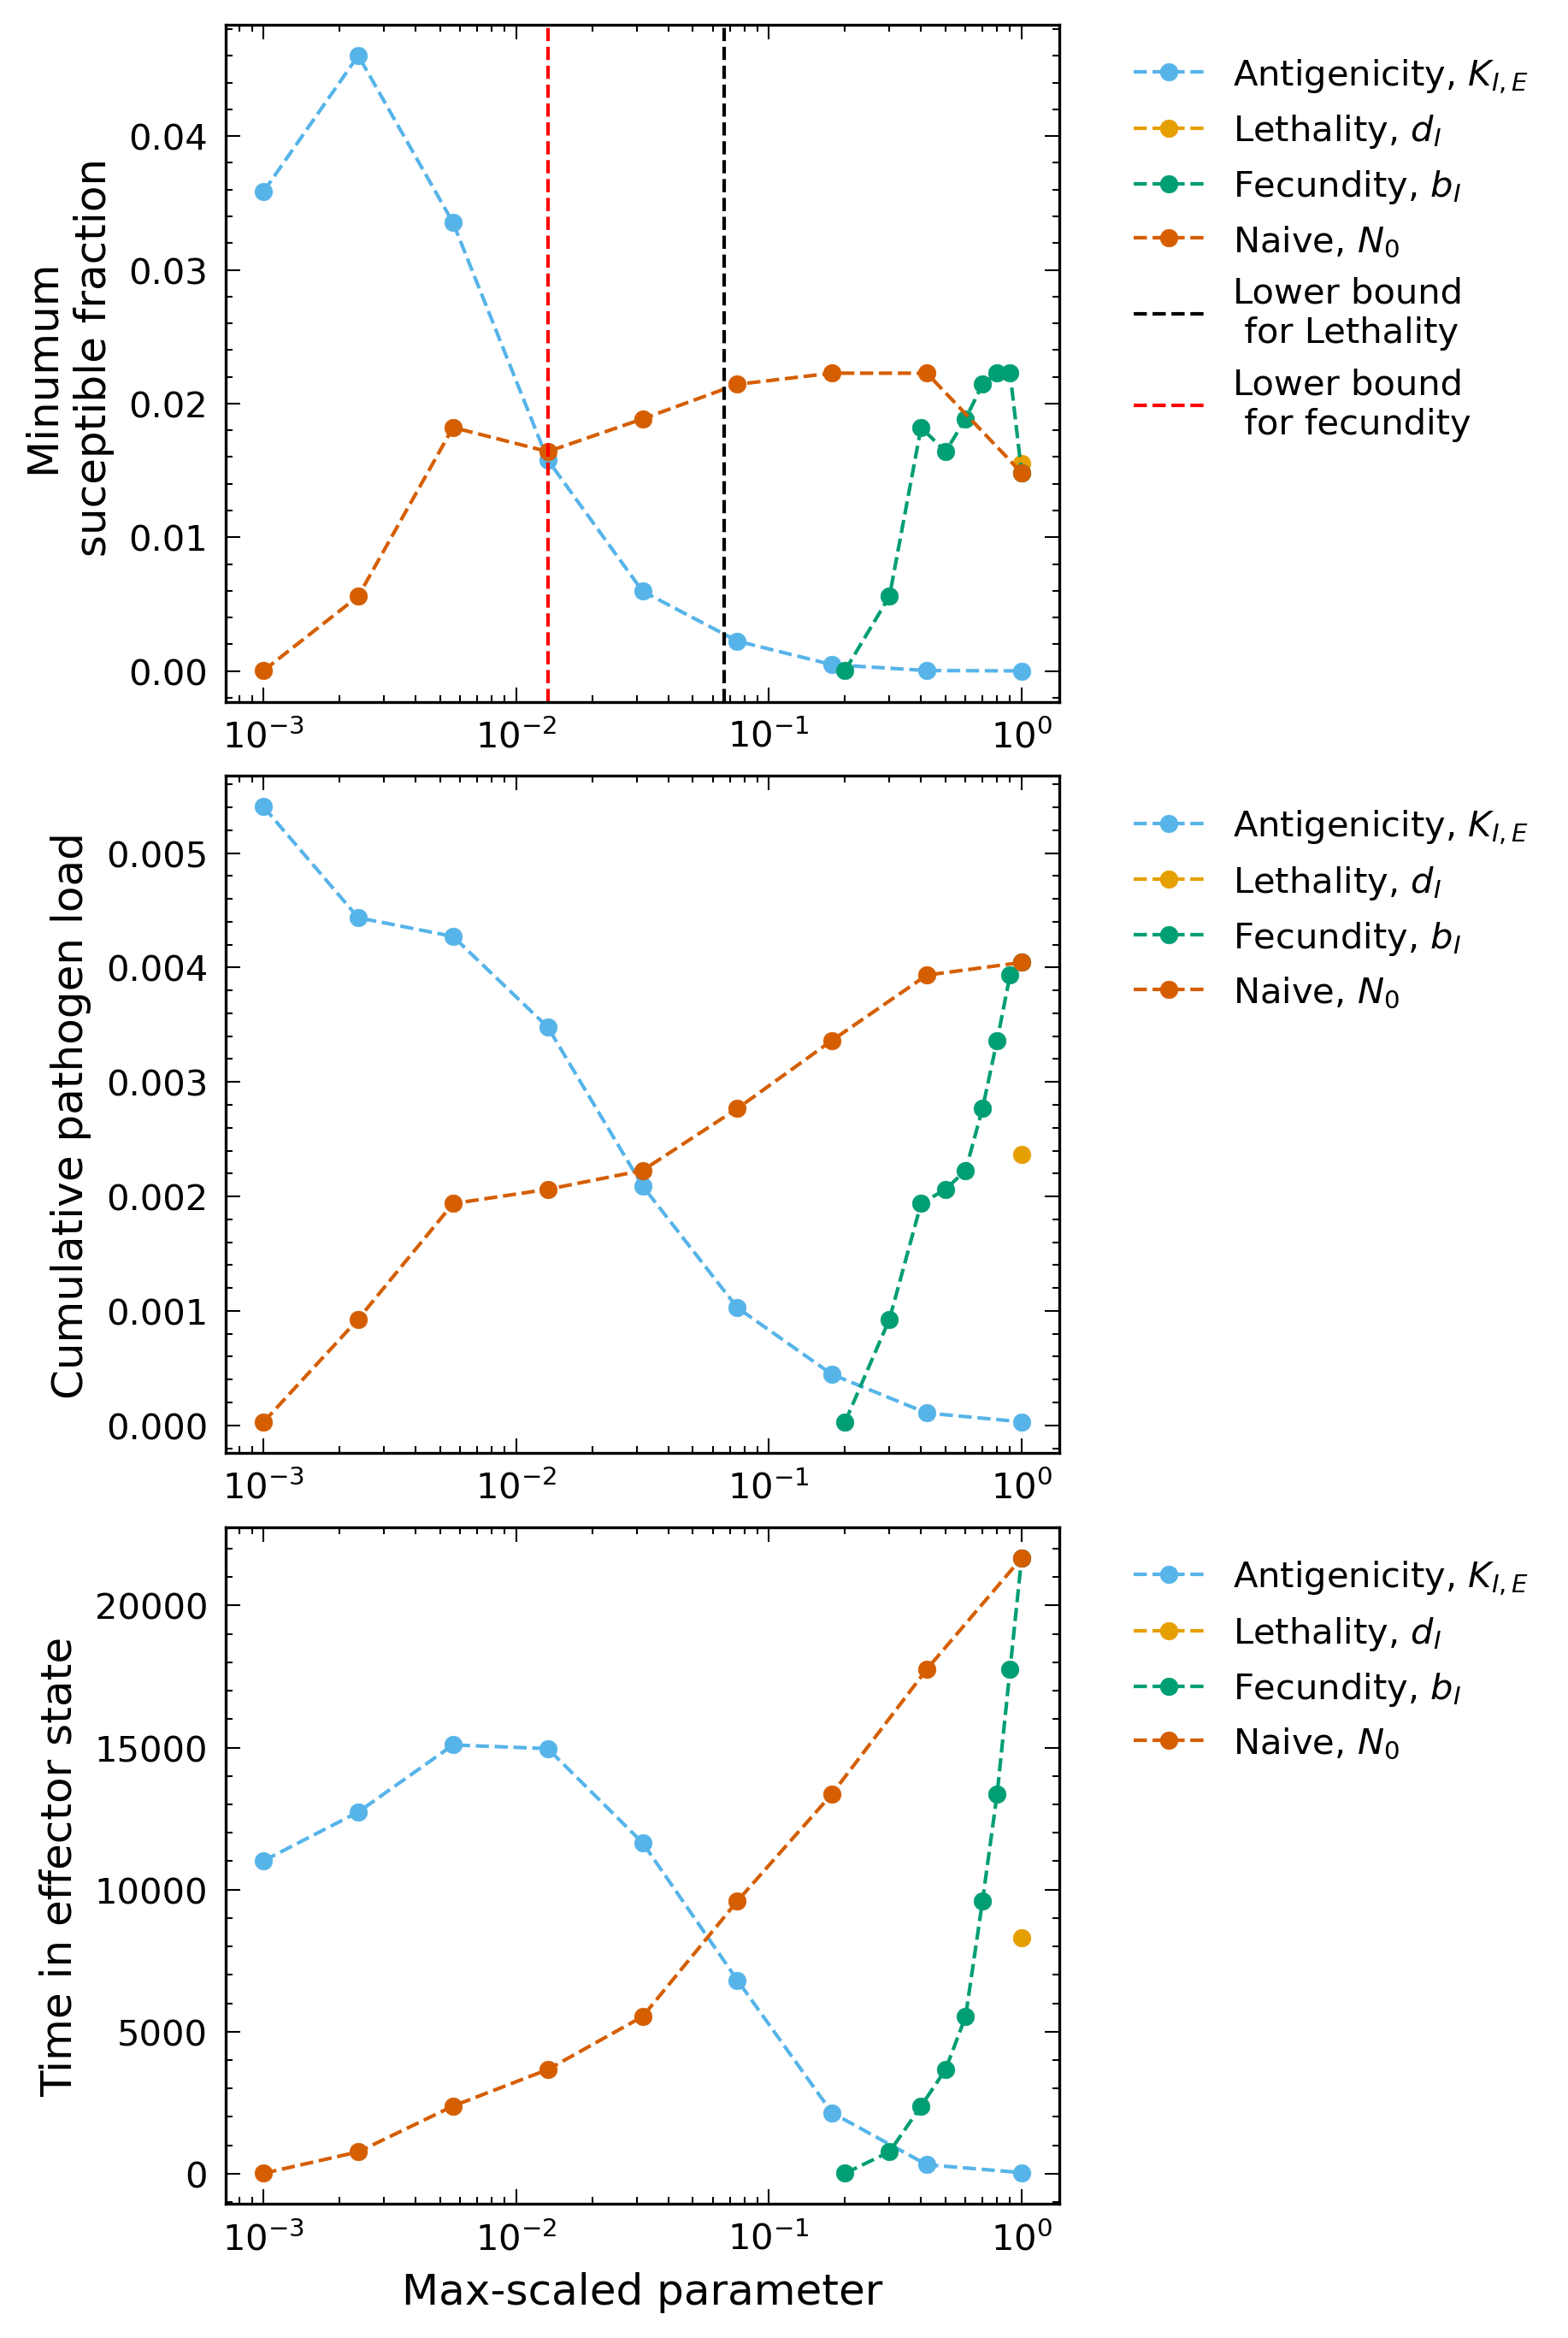

In [17]:
if runs > 1:
    # Plot simulated immune dynamics
    fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))
    
    ax1.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['K_I'], as_index=False).mean()['peff_total_harm'], 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['peff_total_harm'], 'o--', label = 'Lethality, $d_{I}$')
    ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['peff_total_harm'], 'o--', label = 'Fecundity, $b_{I}$')
    ax1.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['peff_total_harm'], 'o--', label = 'Naive, $N_0$')
    ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
    ax1.axvline(x = 1/(sim_duration*S_max)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
    ax1.semilogx()
    ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax1.set(ylabel = 'Minumum \n suceptible fraction')
    
    ax2.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['K_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Lethality, $d_{I}$')
    ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Fecundity, $b_{I}$')
    ax2.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Naive, $N_0$')
    ax2.semilogx()
    ax2.set(ylabel = 'Cumulative pathogen load')
    ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    ax3.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['K_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Lethality, $d_{I}$')
    ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Fecundity, $b_{I}$')
    ax3.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Naive, $N_0$')
    ax3.set(ylabel = 'Time in effector state', xlabel = 'Max-scaled parameter')
    ax3.semilogx()
    ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    
    plt.savefig('_figs/vir_parameter_lineplots_noise', dpi=300, bbox_inches='tight')

### Understand Performance distrubution of the simulations

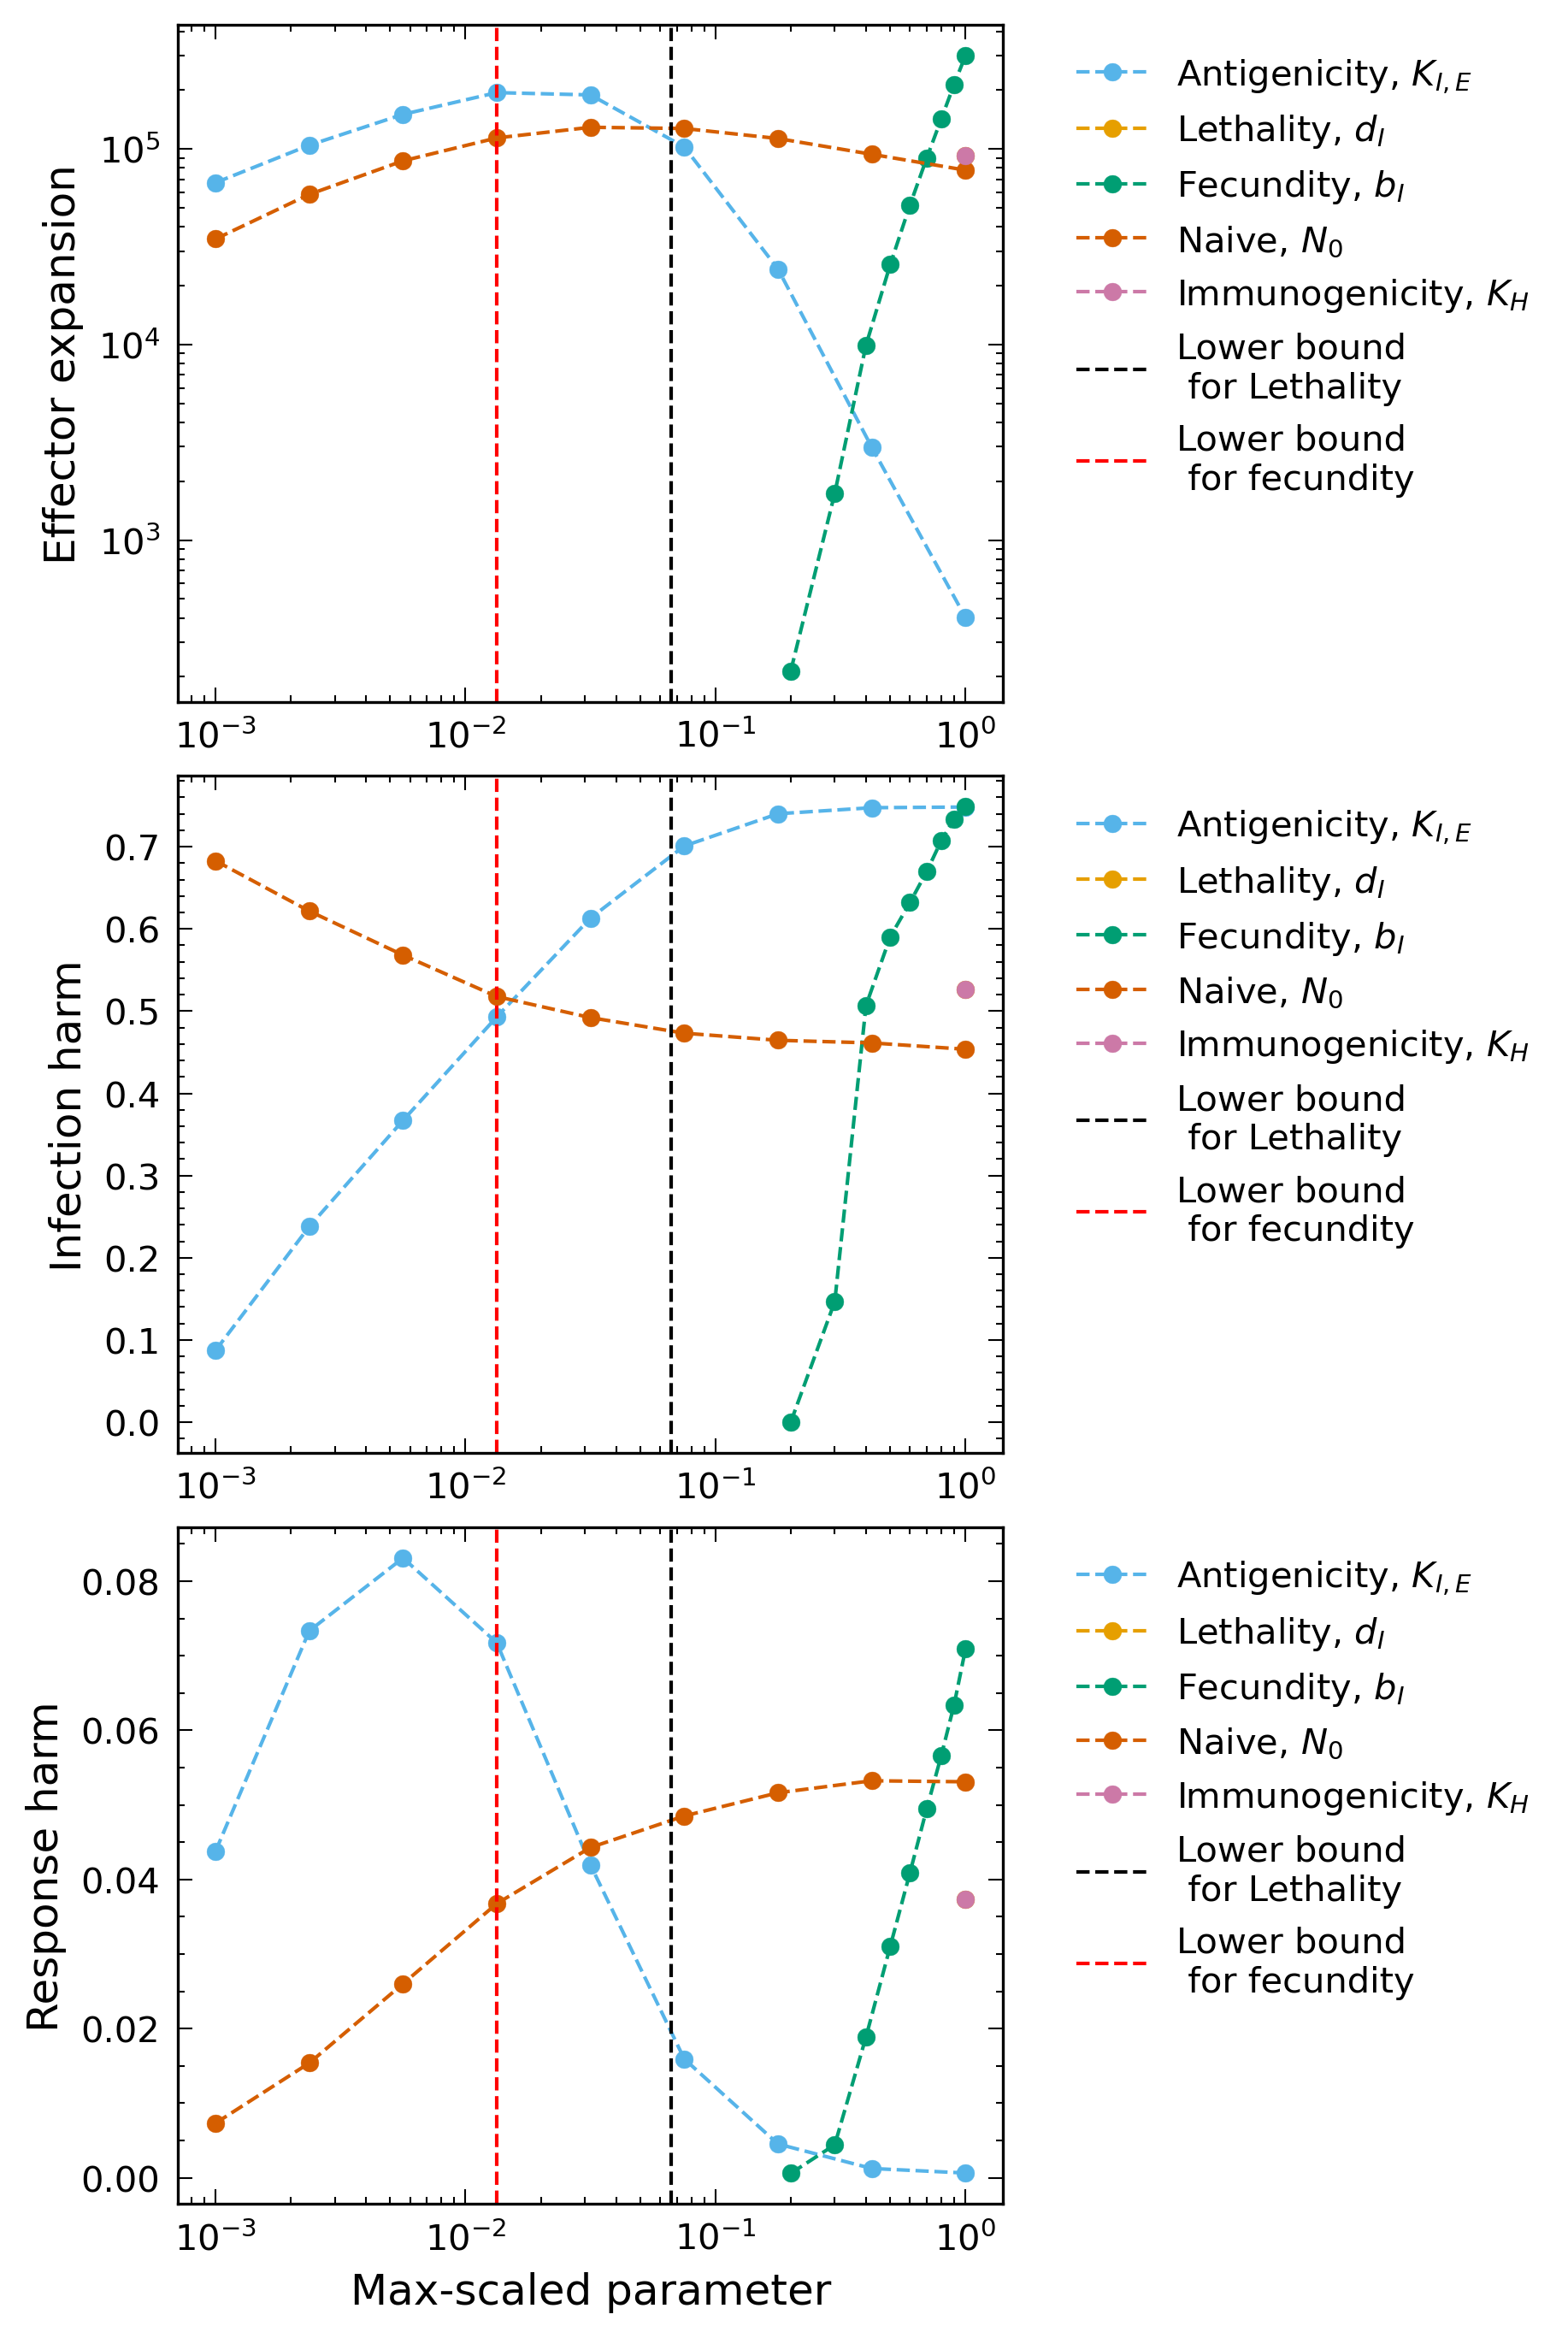

In [18]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))

ax1.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Lethality, $d_{I}$')
ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['max_expE'], 'o--', label = 'Fecundity, $b_{I}$')
ax1.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['N_0'], as_index=False).mean()['max_expE'], 'o--', label = 'Naive, $N_0$')
ax1.plot(use_data.groupby(['K_H'], as_index=False).mean()['K_H']/np.max(use_data['K_H']), use_data.groupby(['K_H'], as_index=False).mean()['max_expE'], 'o--', label = 'Immunogenicity, $K_H$')
ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax1.axvline(x = 1/(sim_duration*S_max)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Effector expansion')

ax2.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I'], as_index=False).mean()['harm_pI']/S_max, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['harm_pI']/S_max, 'o--', label = 'Lethality, $d_{I}$')
ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['harm_pI']/S_max, 'o--', label = 'Fecundity, $b_{I}$')
ax2.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['N_0'], as_index=False).mean()['harm_pI']/S_max, 'o--', label = 'Naive, $N_0$')
ax2.plot(use_data.groupby(['K_H'], as_index=False).mean()['K_H']/np.max(use_data['K_H']), use_data.groupby(['K_H'], as_index=False).mean()['harm_pI']/S_max, 'o--', label = 'Immunogenicity, $K_H$')
ax2.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax2.axvline(x = 1/(sim_duration*S_max)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Infection harm')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Lethality, $d_{I}$')
ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Fecundity, $b_{I}$')
ax3.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['N_0'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Naive, $N_0$')
ax3.plot(use_data.groupby(['K_H'], as_index=False).mean()['K_H']/np.max(use_data['K_H']), use_data.groupby(['K_H'], as_index=False).mean()['harm_pS']/S_max, 'o--', label = 'Immunogenicity, $K_H$')
ax3.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax3.axvline(x = 1/(sim_duration*S_max)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Response harm', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

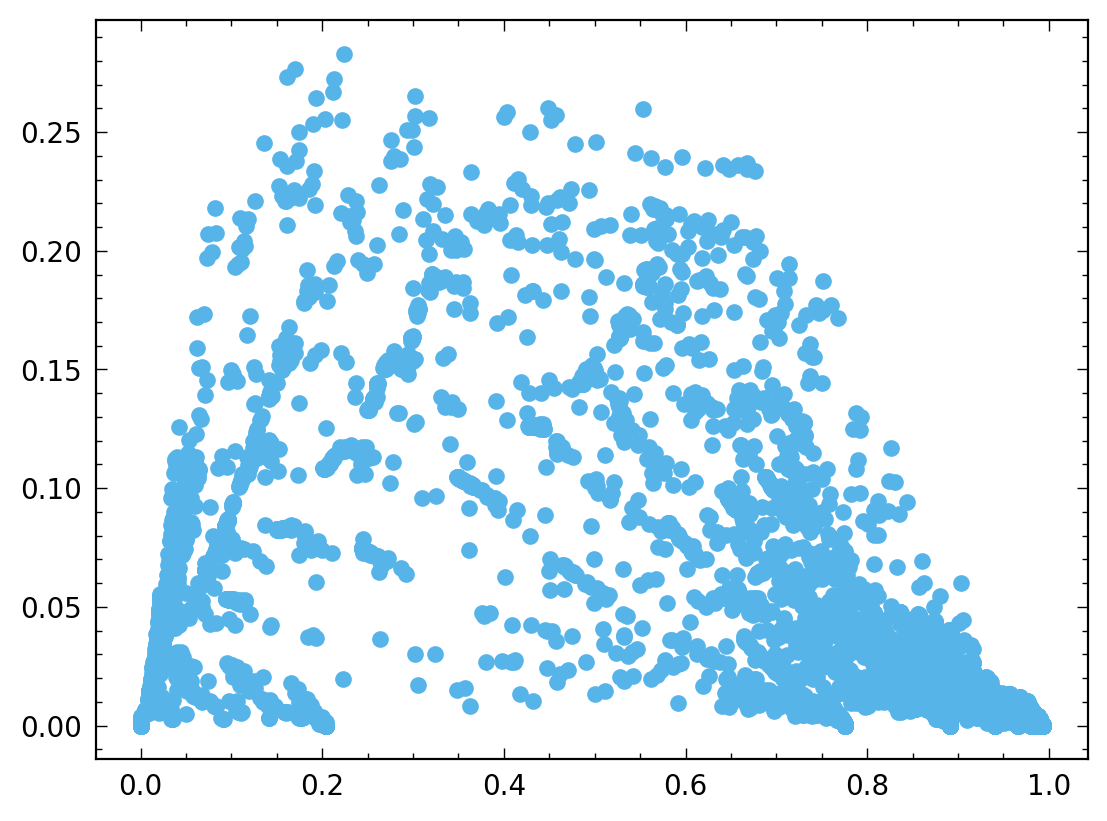

In [19]:
plt.scatter(use_data.harm_pI/S_max, use_data.harm_pS/S_max)
# plt.semilogx()
# plt.semilogy()

RuntimeError: Error in qhull Delaunay triangulation calculation: singular input data (exitcode=2); use python verbose option (-v) to see original qhull error.

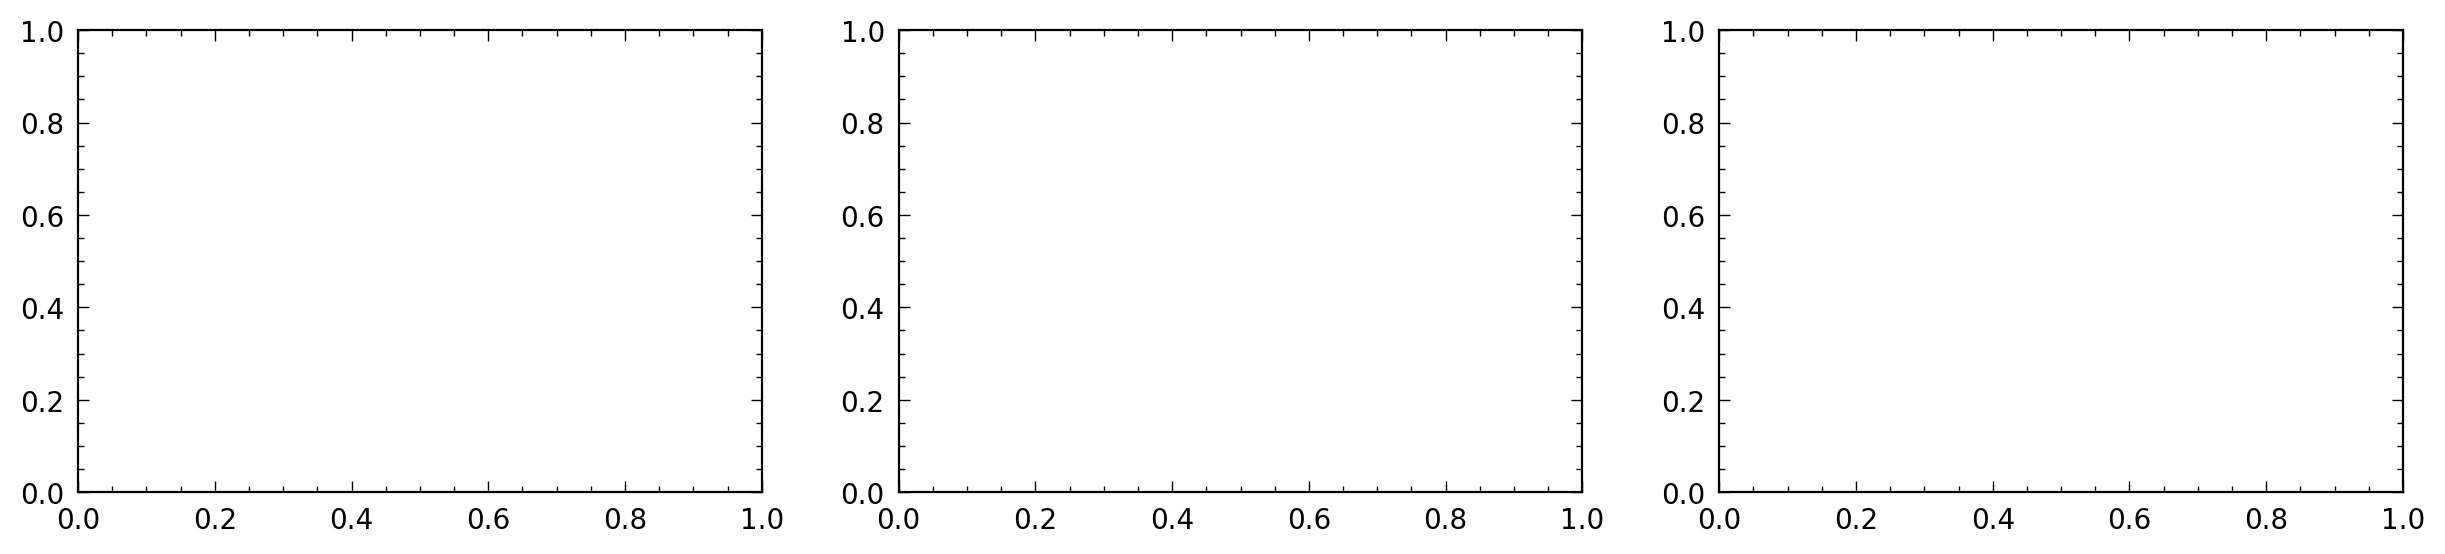

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], 
                  use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['K_I','d_I'], as_index=False).mean()['harm_pI']/S_max, linewidths=0.1, colors='k')
im0 = axs[0].tricontourf(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], 
                        use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['K_I','d_I'], as_index=False).mean()['harm_pI']/S_max, cmap="Purples", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], 
                  use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['K_I','b_I'], as_index=False).mean()['harm_pI']/S_max, linewidths=0.1, colors='k')
im1 = axs[1].tricontourf(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], 
                        use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['K_I','b_I'], as_index=False).mean()['harm_pI']/S_max, cmap="Purples", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI']/S_max, linewidths=0.1, colors='k')
im2 = axs[2].tricontourf(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI']/S_max, cmap="Purples",norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Fecundity $b_I$ vs. Lethality $d_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 3), sharex=False, sharey=False)

size = 4250/num_pnts

plot_data = use_data.groupby(['K_I','d_I'], as_index=False).mean()
im0 = axs[0].scatter(S_max/plot_data['K_I'], plot_data['d_I']/d_S, marker = 's', s = size,
                    c = plot_data['harm_pI']/S_max, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['K_I','b_I'], as_index=False).mean()
im1 = axs[1].scatter(S_max/plot_data['K_I'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['harm_pI']/S_max, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['b_I','d_I'], as_index=False).mean()
im2 = axs[2].scatter(plot_data['d_I']/d_S, plot_data['b_I'], marker = 's', s = size,
               c = plot_data['harm_pI']/S_max, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['N_0','K_I'], as_index=False).mean()
im3 = axs[3].scatter(S_max/plot_data['K_I'], plot_data['N_0']/N_0, marker = 's', s = size,
               c = plot_data['harm_pI']/S_max, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im3, ax=axs[3], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

axs[0].set_title(r"Antigenicity, $\frac{S_{max}}{K_{I}}$ vs. Lethality, $\frac{d_I}{d_S}$", fontsize = 10)
axs[1].set_title(r"Antigenicity, $\frac{S_{max}}{K_{I}}$ vs. Fecundity, $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality, $\frac{d_I}{d_S}$ vs. Fecundity, $b_I$", fontsize = 10)
axs[3].set_title(r"Antigenicity, $\frac{S_{max}}{K_{I}}$ vs. Naive, $N_0$", fontsize = 10)

axs[0].set_ylabel(r"Lethality, $\frac{d_I}{d_S}$", fontsize = 12)
axs[0].set_xlabel(r"Antigenicity, $\frac{S_{max}}{K_{I}}$", fontsize = 12)
axs[1].set_ylabel(r"Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel(r"Antigenicity, $\frac{S_{max}}{K_{I}}$", fontsize = 12)
axs[2].set_ylabel(r"Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel(r"Lethality, $\frac{d_I}{d_S}$", fontsize = 12)
axs[3].set_ylabel(r"Naive, $N_0$", fontsize = 12)
axs[3].set_xlabel(r"Antigenicity, $\frac{S_{max}}{K_{I}}$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()
axs[3].semilogx()
axs[3].semilogy()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['p_load'], cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['p_load'], cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['p_load'], cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}^{-1}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}^{-1}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pharm_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(S_max/use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['harm_pS']/S_max, cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im1 = axs[1].scatter(S_max/use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['harm_pS']/S_max, cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im2 = axs[2].scatter(S_max/use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pS']/S_max, cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_toxicity_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_duration_heatmaps', dpi=300, bbox_inches='tight')